In [6]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np

In [7]:
res = pd.read_csv("results.csv")
res

,Unnamed: 0,trial_id,iteration,test_metric,strategy,seed,score
0,0,6dc81_00000,0,0.475539,least_confidence,1,1259.679678
1,1,6dc81_00000,1,0.593943,least_confidence,1,1259.679678
2,2,6dc81_00000,2,0.603038,least_confidence,1,1259.679678
3,3,6dc81_00000,3,0.514314,least_confidence,1,1259.679678
4,4,6dc81_00000,4,0.575333,least_confidence,1,1259.679678
...,...,...,...,...,...,...,...
31970,31970,6dc81_00024,1274,0.994999,random,5,1246.817912
31971,31971,6dc81_00024,1275,0.997549,random,5,1246.817912
31972,31972,6dc81_00024,1276,0.997549,random,5,1246.817912
31973,31973,6dc81_00024,1277,0.994999,random,5,1246.817912


In [8]:
res[res.strategy=="random"]

,Unnamed: 0,trial_id,iteration,test_metric,strategy,seed,score
25580,25580,6dc81_00020,0,0.767810,random,1,1239.388812
25581,25581,6dc81_00020,1,0.475539,random,1,1239.388812
25582,25582,6dc81_00020,2,0.570133,random,1,1239.388812
25583,25583,6dc81_00020,3,0.750679,random,1,1239.388812
25584,25584,6dc81_00020,4,0.492500,random,1,1239.388812
...,...,...,...,...,...,...,...
31970,31970,6dc81_00024,1274,0.994999,random,5,1246.817912
31971,31971,6dc81_00024,1275,0.997549,random,5,1246.817912
31972,31972,6dc81_00024,1276,0.997549,random,5,1246.817912
31973,31973,6dc81_00024,1277,0.994999,random,5,1246.817912


In [9]:
aucs = res.drop_duplicates(subset=["strategy","seed"])
agg = aucs.groupby("strategy")["score"]
mean_aucs, std_aucs = agg.mean(), agg.std()
aucs = pd.concat((mean_aucs, std_aucs), axis=1)
aucs.columns = ["avg", "stdv"]
aucs["score"] = aucs.apply(lambda row: f"{row.avg:.2f} ± {row.stdv:.2f}"  ,axis=1)
label_to_auc = dict(zip(aucs.index, aucs["score"]))

/var/folders/02/fbyrwz_s7tg4vmbm1kswhxp40000gp/T/ipykernel_29466/2952143151.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([int(label) + 10 for label in current_xticks])


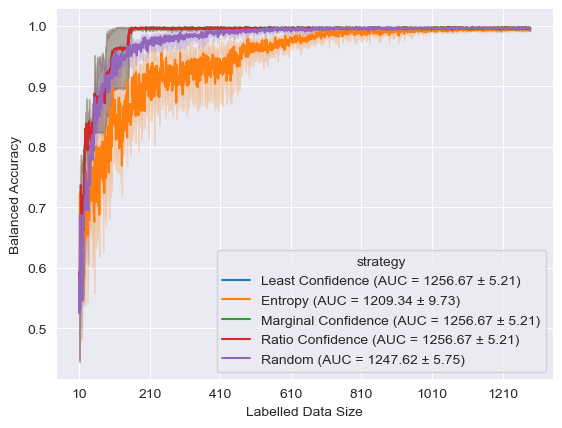

In [10]:
sns.set_style("darkgrid")

sns.lineplot(data=res, x="iteration", y="test_metric", hue="strategy")
plt.ylabel("Balanced Accuracy")
plt.xlabel("Labelled Data Size")

current_xticks = plt.gca().get_xticks()
plt.gca().set_xticklabels([int(label) + 10 for label in current_xticks])

ax = plt.gca()
legend = ax.get_legend()
for text in legend.get_texts():
    label = text.get_text()
    new_label = f"{label.replace('_', ' ').title()} (AUC = {label_to_auc[label]})"
    text.set_text(new_label)
    

for spine in ax.spines.values():
    spine.set_visible(False)